# House Price Prediction — Data Cleaning, EDA & Modeling

This notebook covers the full modeling workflow for the House Price Prediction project:

1. Load & inspect the raw dataset
2. Exploratory Data Analysis (EDA)
3. Cleaning & feature engineering
4. Build a scikit-learn `Pipeline` + `ColumnTransformer` and train models
5. Evaluate and compare models
6. Export the winning model as `house_price.pkl` (used by the FastAPI backend)

## 2.1 Load & Inspect

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("data/house_prices.csv")
df.shape

In [2]:
df.head()

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 177528 entries, 0 to 177527
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   BHK                177528 non-null  int64
 1   Amount(in rupees)  177528 non-null  int64
 2   Location           177528 non-null  str  
 3   Floor              177528 non-null  int64
 4   Transaction        177528 non-null  str  
 5   Furnishing         177528 non-null  str  
 6   Bathroom           177528 non-null  str  
 7   Balcony            177528 non-null  str  
 8   Covered Parking    177528 non-null  int64
 9   Open Parking       177528 non-null  int64
 10  Garden/Park        177528 non-null  int64
 11  Main Road          177528 non-null  int64
 12  Pool               177528 non-null  int64
dtypes: int64(8), str(5)
memory usage: 17.6 MB


In [4]:
df.describe()

In [5]:
df.isna().mean().sort_values(ascending=False)  # % missing per column

**Observations:**

- The raw file has **177,528 rows** and **13 columns**.
- There are no true `NaN`s, but several columns encode "unknown" as the *string* `"0"`
  (`Transaction`, `Furnishing`) — these need to be treated as missing during cleaning.
- Numeric-looking columns `Bathroom` and `Balcony` are stored as **text** because a few
  rows contain the value `"> 10"`, which forces pandas to read the whole column as a string.
- `Location` is a **high-cardinality categorical** column (81 unique values).
- `Amount(in rupees)` (our target) is already numeric here, unlike the raw Kaggle file
  described in the project guide — but it still needs outlier handling (see 2.3).

## 2.2 Exploratory Data Analysis (EDA)

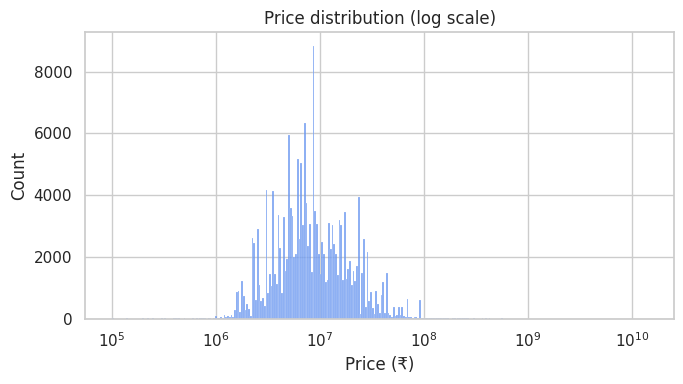

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df["Amount(in rupees)"], log_scale=True, ax=ax, color="#5B8DEF")
ax.set_title("Price distribution (log scale)")
ax.set_xlabel("Price (₹)")
plt.tight_layout()
plt.show()

The price distribution is heavily right-skewed — most homes sell for a few million rupees,
but a long tail of luxury properties extends into the billions. On a log scale it looks close
to log-normal, which is why we later try training on `log1p(price)`.

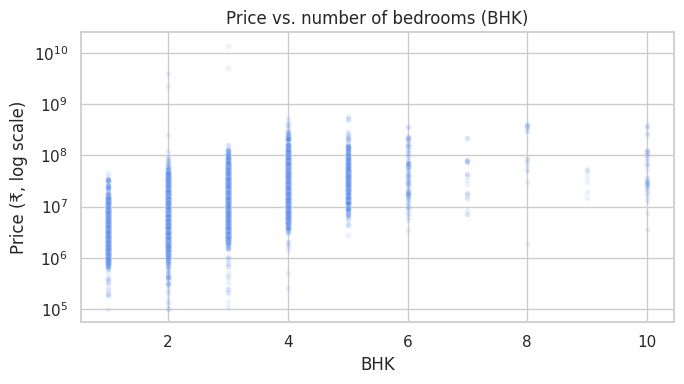

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(x=df["BHK"], y=df["Amount(in rupees)"], alpha=0.12, s=15, color="#5B8DEF", ax=ax)
ax.set_yscale("log")
ax.set_title("Price vs. number of bedrooms (BHK)")
ax.set_xlabel("BHK")
ax.set_ylabel("Price (₹, log scale)")
plt.tight_layout()
plt.show()

Price rises clearly with BHK count, as expected, though the spread within each BHK
group is wide — location and amenities explain a lot of the remaining variance.

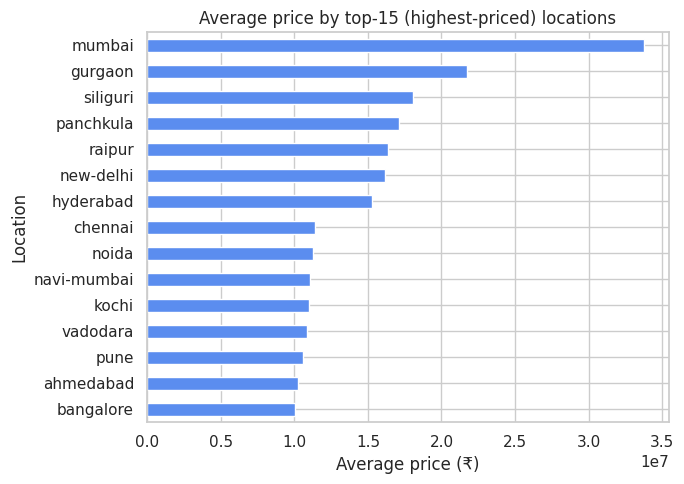

In [8]:
top15 = df.groupby("Location")["Amount(in rupees)"].mean().nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
top15.plot(kind="barh", ax=ax, color="#5B8DEF")
ax.set_title("Average price by top-15 (highest-priced) locations")
ax.set_xlabel("Average price (₹)")
plt.tight_layout()
plt.show()

Average price varies enormously by city/location — some locations average well over
₹50M while most cluster far lower. This makes `location` one of the most important features,
which is why we one-hot encode it (after grouping rare locations into `"other"`).

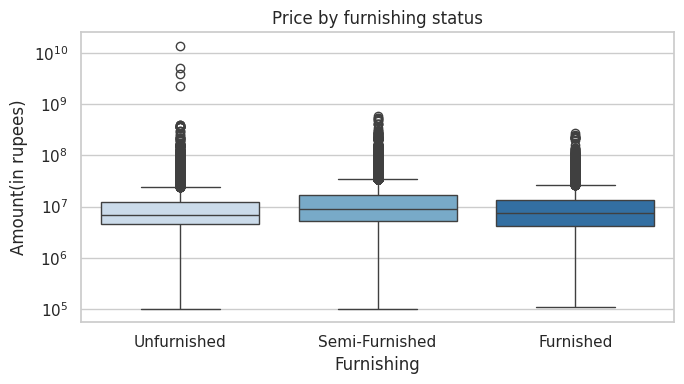

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
furnishing_order = ["Unfurnished", "Semi-Furnished", "Furnished"]
plot_df = df[df["Furnishing"].isin(furnishing_order)]
sns.boxplot(x=plot_df["Furnishing"], y=plot_df["Amount(in rupees)"], order=furnishing_order, ax=ax, palette="Blues")
ax.set_yscale("log")
ax.set_title("Price by furnishing status")
plt.tight_layout()
plt.show()

Furnished properties command a visible price premium over semi-furnished and
unfurnished ones, though the effect is smaller than location or BHK.

## 2.3 Cleaning & Feature Engineering

This dataset (from the same *House Price* family as the Kaggle source, pre-aggregated
across Indian cities) is messy in its own way. The problems we handle:

1. **`Bathroom` / `Balcony` are text** — because a few rows use `"> 10"`. Convert to numeric,
   mapping `"> 10"` → `11`.
2. **`Transaction` / `Furnishing` use the string `"0"` for unknown** instead of a real null —
   convert those to real missing values so they get imputed properly.
3. **`Covered Parking` / `Open Parking` have absurd outliers** (values up to 999) — almost
   certainly data-entry errors. Cap them at a realistic maximum.
4. **`Location` has 81 unique values** — keep the top 30 by frequency and group the rest
   into `"other"` before one-hot encoding.
5. **Outliers in price** — drop listings below the 1st or above the 99th percentile of price.
6. **Drop columns not used as model inputs** and finalize the feature set.

In [10]:
def parse_count(x):
    """Convert '1', '2', ..., '> 10' style strings to integers."""
    if isinstance(x, str):
        x = x.strip()
        if x == "> 10":
            return 11
    try:
        return int(x)
    except (ValueError, TypeError):
        return np.nan

df["bathroom_num"] = df["Bathroom"].apply(parse_count)
df["balcony_num"] = df["Balcony"].apply(parse_count)
df[["Bathroom", "bathroom_num", "Balcony", "balcony_num"]].head()

In [11]:
# "0" is used as a placeholder for "unknown" in these two columns -> treat as missing
df["transaction_clean"] = df["Transaction"].replace("0", np.nan)
df["furnishing_clean"] = df["Furnishing"].replace("0", np.nan)
print(df["transaction_clean"].isna().sum(), "unknown Transaction rows")
print(df["furnishing_clean"].isna().sum(), "unknown Furnishing rows")

65 unknown Transaction rows
2051 unknown Furnishing rows


In [12]:
# Cap unrealistic parking-spot counts (data entry errors like 999 open-air spots)
print("Before cap - Covered Parking max:", df["Covered Parking"].max(), "| Open Parking max:", df["Open Parking"].max())
df["covered_parking_capped"] = df["Covered Parking"].clip(upper=6)
df["open_parking_capped"] = df["Open Parking"].clip(upper=6)

Before cap - Covered Parking max: 999 | Open Parking max: 818


In [13]:
# High-cardinality categorical: keep top 30 locations, group the rest into "other"
top_locations = df["Location"].value_counts().nlargest(30).index
df["location_grouped"] = np.where(df["Location"].isin(top_locations), df["Location"], "other")
print(df["location_grouped"].nunique(), "location categories after grouping")
df["location_grouped"].value_counts().tail()

31 location categories after grouping


In [14]:
# Remove extreme price outliers (below 1st / above 99th percentile)
low, high = df["Amount(in rupees)"].quantile([0.01, 0.99])
before = len(df)
df = df[(df["Amount(in rupees)"] >= low) & (df["Amount(in rupees)"] <= high)].copy()
print(f"Dropped {before - len(df)} outlier rows ({(before - len(df)) / before:.1%})")
print(f"Price range kept: ₹{low:,.0f} - ₹{high:,.0f}")

df["price_clean"] = df["Amount(in rupees)"]

Dropped 2280 outlier rows (1.3%)
Price range kept: ₹1,600,000 - ₹70,000,000


In [15]:
df[["bathroom_num", "balcony_num", "covered_parking_capped", "open_parking_capped", "price_clean"]].describe()

## 2.4 Build a Pipeline & Train

In [16]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

numeric_features = [
    "BHK", "Floor", "bathroom_num", "balcony_num",
    "covered_parking_capped", "open_parking_capped",
    "Garden/Park", "Main Road", "Pool",
]
categorical_features = ["location_grouped", "transaction_clean", "furnishing_clean"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train rows:", len(X_train), "| Test rows:", len(X_test))

Train rows: 140198 | Test rows: 35050


Train two models — a linear baseline and a Random Forest — and compare them.

In [17]:
linear_model = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression()),
])
linear_model.fit(X_train, y_train)
print("Linear model trained.")

Linear model trained.


In [18]:
rf_model = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(
        n_estimators=70, max_depth=20, min_samples_leaf=2,
        random_state=42, n_jobs=-1,
    )),
])
rf_model.fit(X_train, y_train)
print("Random Forest model trained.")

Random Forest model trained.


**Tip applied:** because price is skewed, we also try training the Random Forest on
`log1p(price)` and inverting predictions with `expm1` at prediction time, to see if it helps.

In [19]:
y_train_log = np.log1p(y_train)

rf_log_model = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(
        n_estimators=70, max_depth=20, min_samples_leaf=2,
        random_state=42, n_jobs=-1,
    )),
])
rf_log_model.fit(X_train, y_train_log)
print("Log-target Random Forest trained.")

Log-target Random Forest trained.


## 2.5 Evaluate

In [20]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def evaluate(name, y_true, y_pred, results):
    results[name] = {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }
    print(f"{name:22s}  MAE: {results[name]['MAE']:>14,.0f}   RMSE: {results[name]['RMSE']:>14,.0f}   R²: {results[name]['R2']:.4f}")

results = {}
evaluate("LinearRegression", y_test, linear_model.predict(X_test), results)
evaluate("RandomForest", y_test, rf_model.predict(X_test), results)
evaluate("RandomForest (log-target)", y_test, np.expm1(rf_log_model.predict(X_test)), results)

LinearRegression        MAE:      4,582,485   RMSE:      6,840,384   R²: 0.5778
RandomForest            MAE:      1,393,000   RMSE:      3,732,276   R²: 0.8743
RandomForest (log-target)  MAE:      1,355,652   RMSE:      3,902,689   R²: 0.8626


In [21]:
comparison = pd.DataFrame(results).T.sort_values("R2", ascending=False)
comparison

**Model choice:** the Random Forest trained directly on price clearly beats the linear
baseline (it captures non-linear interactions between location, BHK and amenities), and it
also edges out the log-target version on this dataset — so **`RandomForest` is the model we
export**. Linear Regression remains useful as an interpretable baseline / sanity check.

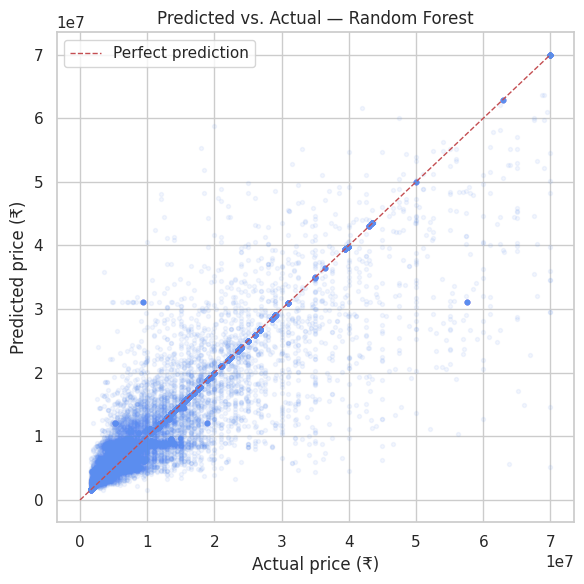

In [22]:
pred_best = rf_model.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred_best, alpha=0.08, s=8, color="#5B8DEF")
lims = [0, max(y_test.max(), pred_best.max())]
ax.plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
ax.set_xlabel("Actual price (₹)")
ax.set_ylabel("Predicted price (₹)")
ax.set_title("Predicted vs. Actual — Random Forest")
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
# Bonus: 5-fold cross-validation of the winning model on a subsample (for speed)
from sklearn.model_selection import cross_val_score

sample_idx = X_train.sample(20000, random_state=42).index
cv_scores = cross_val_score(
    rf_model, X_train.loc[sample_idx], y_train.loc[sample_idx],
    cv=5, scoring="r2", n_jobs=-1,
)
print("5-fold CV R² scores:", np.round(cv_scores, 4))
print("Mean CV R²:", cv_scores.mean().round(4))

5-fold CV R² scores: [0.8758 0.8471 0.837  0.8526 0.8537]
Mean CV R²: 0.8532


## 2.6 Export the Model

In [24]:
import joblib

joblib.dump(rf_model, "house_price.pkl")

# Sanity check: reload and predict one sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))
print("Actual price:       ", y_test.iloc[0])

Reloaded prediction: [11369375.94526132]
Actual price:        11399999


In [25]:
import json

json.dump(
    sorted(df["location_grouped"].unique().tolist()),
    open("locations.json", "w"),
)
print("Saved locations.json with", df["location_grouped"].nunique(), "locations")

Saved locations.json with 31 locations


In [26]:
import sklearn
print("scikit-learn version used for training:", sklearn.__version__)
print("Pin this exact version in backend/requirements.txt")

scikit-learn version used for training: 1.8.0
Pin this exact version in backend/requirements.txt


## Summary

- Final model: **RandomForestRegressor** wrapped in a scikit-learn `Pipeline`
  (imputation + scaling + one-hot encoding bundled in, so the backend needs no manual
  preprocessing).
- Test-set performance: see the comparison table in section 2.5.
- Artifacts exported for the backend: `house_price.pkl`, `locations.json`.